## Clustering and Plotting 2D data

A K-means clustering example using scikit-learn's KMeans on 2D data points is demonstrated as follows:

1. Original Data Plot:
   - Plot the original data in 2D.

2. K-means Clustering:
   - Perform K-means clustering on the data.

3. Cluster Visualization:
   - Plot another graph where points in each cluster are colored separately.

4. Tightness Score:
   - Calculate and print the tightness score of the clustering.

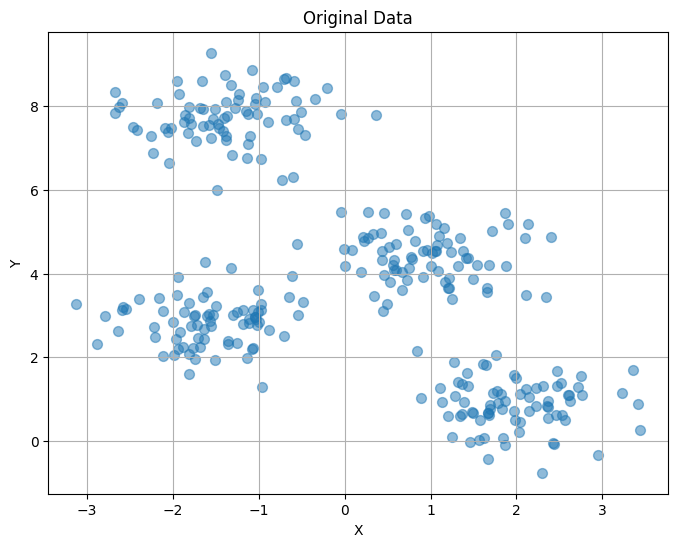

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

# Generate random 2D data points
X, _ = make_blobs(n_samples=300, centers=4, cluster_std=0.60, random_state=0)

# Plot the original data
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], s=50, alpha=0.5)
plt.title("Original Data")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid(True)
plt.show()

# Apply K-means and show cluster tightness / distortion



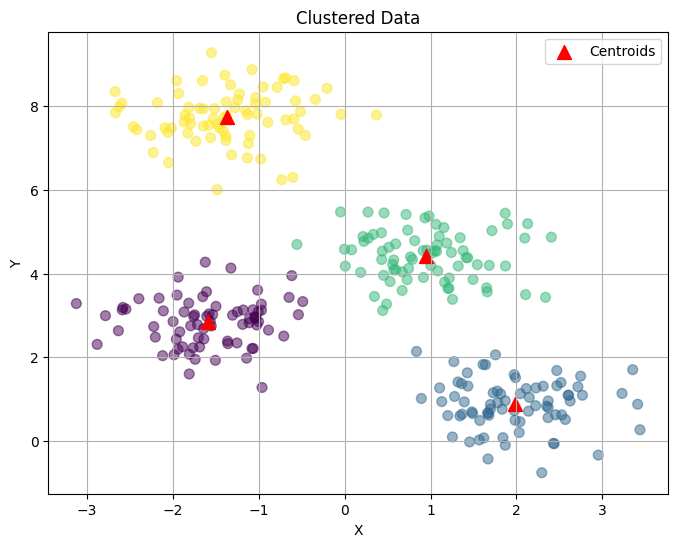

Cluster inertia = 212.00599621083475


In [2]:
# Perform K-means clustering
kmeans = KMeans(n_clusters=4)
kmeans.fit(X)
labels = kmeans.predict(X)
centroids = kmeans.cluster_centers_

# Plot the clustered data
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=labels, s=50, cmap='viridis', alpha=0.5)
plt.scatter(centroids[:, 0], centroids[:, 1], marker='^', c='red', s=100, label='Centroids')
plt.title("Clustered Data")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.grid(True)
plt.show()

# Calculate cluster inertia
inertia = kmeans.inertia_
print(f"Cluster inertia = {inertia}")


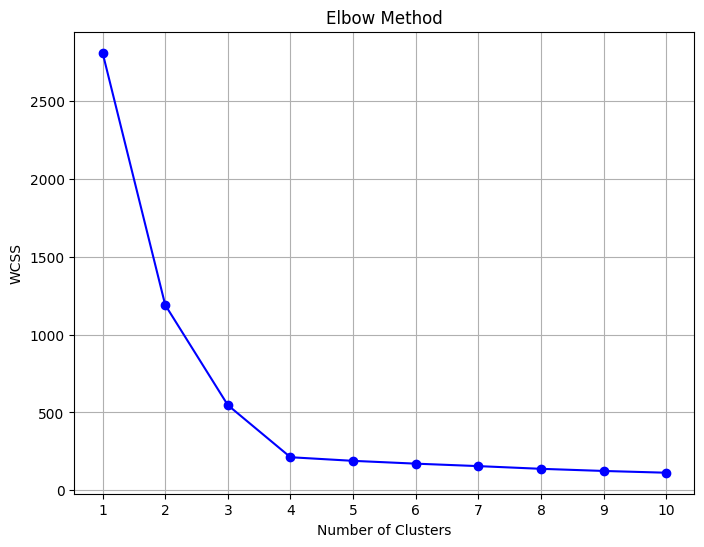

In [3]:
# Calculate WCSS for different numbers of clusters
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=0)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

# Plot the elbow curve
plt.figure(figsize=(8, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='-', color='b')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()